In [2]:
import sqlite3

import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("NIFTY_50.csv")

In [4]:
df

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,16-JUL-2026,24142.10,24186.50,24050.00,24072.75,264271962,24244.17
1,15-JUL-2026,24085.85,24220.35,24010.55,24078.50,306924577,26842.00
2,14-JUL-2026,24068.00,24157.10,24023.70,24052.05,355829008,31700.08
3,13-JUL-2026,24039.40,24259.80,24000.20,24211.00,322678968,27998.31
4,10-JUL-2026,24124.70,24228.45,24120.35,24206.90,313072212,24577.43
...,...,...,...,...,...,...,...
2476,15-JUL-2016,8565.45,8594.80,8510.05,8541.40,228598684,12375.84
2477,14-JUL-2016,8515.75,8571.40,8500.70,8565.00,158738499,6890.07
2478,13-JUL-2016,8540.45,8550.25,8493.55,8519.50,201492184,8284.38
2479,12-JUL-2016,8502.60,8526.60,8479.20,8521.05,189339750,7873.74


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2481 entries, 0 to 2480
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             2481 non-null   str    
 1   Open             2481 non-null   float64
 2   High             2481 non-null   float64
 3   Low              2481 non-null   float64
 4   Close            2481 non-null   float64
 5   Shares Traded    2481 non-null   int64  
 6   Turnover (₹ Cr)  2481 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 162.5 KB


In [6]:
# Remove leading/trailing spaces from all column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']


In [7]:
# Drop unnecessary column
df = df.drop(columns=["Turnover (₹ Cr)"])

# Rename column
df = df.rename(columns={"Shares Traded": "Volume"})

In [8]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%Y")

# Check duplicate dates
duplicates = df[df.duplicated(subset="Date", keep=False)]

print(f"Total rows        : {len(df)}")
print(f"Duplicate dates   : {duplicates['Date'].nunique()}")

if not duplicates.empty:
    display(duplicates)

Total rows        : 2481
Duplicate dates   : 0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2481 entries, 0 to 2480
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2481 non-null   datetime64[us]
 1   Open    2481 non-null   float64       
 2   High    2481 non-null   float64       
 3   Low     2481 non-null   float64       
 4   Close   2481 non-null   float64       
 5   Volume  2481 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 116.4 KB


In [10]:
df["Date"].dt.day_name().value_counts()

Date
Thursday     498
Wednesday    498
Tuesday      496
Monday       491
Friday       489
Saturday       5
Sunday         4
Name: count, dtype: int64

In [11]:
df[df["Date"].dt.weekday >= 5][["Date", "Open", "High", "Low", "Close", "Volume"]]

,Date,Open,High,Low,Close,Volume
111,2026-02-01,25333.75,25440.90,24571.75,24825.45,379370206
357,2025-02-01,23528.60,23632.45,23318.30,23482.15,287703637
535,2024-05-18,22512.85,22520.25,22470.05,22502.00,19064566
613,2024-01-20,21706.15,21720.30,21541.80,21571.80,162073740
661,2023-11-12,19547.25,19547.25,19510.25,19525.55,37311902
1402,2020-11-14,12823.35,12828.70,12749.45,12780.25,107868139
1599,2020-02-01,11939.00,12017.35,11633.30,11661.85,537634767
1667,2019-10-27,11662.25,11672.40,11604.60,11627.15,161779004
2405,2016-10-30,8672.35,8678.25,8616.25,8625.70,16610872


In [12]:
# Set Date as index
weekly_df = (
    df.set_index("Date")
      .resample("W-SUN")          # Monday → Sunday
      .agg({
          "Open": "first",
          "High": "max",
          "Low": "min",
          "Close": "last",
          "Volume": "sum"
      })
      .dropna()
      .reset_index()
)

weekly_df.head()

,Date,Open,High,Low,Close,Volume
0,2016-07-17,8413.35,8594.80,8407.05,8541.40,932569050
1,2016-07-24,8564.05,8587.10,8476.70,8541.20,809995964
2,2016-07-31,8519.95,8674.70,8517.20,8638.50,906648267
3,2016-08-07,8654.30,8711.30,8518.15,8683.15,869342096
4,2016-08-14,8712.85,8728.35,8540.05,8672.15,1030230336


In [13]:
weekly_df

,Date,Open,High,Low,Close,Volume
0,2016-07-17,8413.35,8594.80,8407.05,8541.40,932569050
1,2016-07-24,8564.05,8587.10,8476.70,8541.20,809995964
2,2016-07-31,8519.95,8674.70,8517.20,8638.50,906648267
3,2016-08-07,8654.30,8711.30,8518.15,8683.15,869342096
4,2016-08-14,8712.85,8728.35,8540.05,8672.15,1030230336
...,...,...,...,...,...,...
518,2026-06-21,23984.85,24189.25,23817.80,24013.10,1866733566
519,2026-06-28,24106.60,24261.60,23784.95,24056.00,1437242106
520,2026-07-05,24061.75,24378.15,23829.20,24270.85,2089267807
521,2026-07-12,24306.85,24530.90,23805.20,24206.90,1860379944


In [14]:
# ===========================
# Feature 1 : EMA40
# ===========================
weekly_df["EMA40"] = (
    weekly_df["Close"]
    .ewm(span=40, adjust=False)
    .mean()
)

# ===========================
# Feature 2 : EMA40 Slope
# ===========================
EMA_SLOPE_PERIOD = 3

weekly_df["EMA40_Slope"] = (
    weekly_df["EMA40"].diff(EMA_SLOPE_PERIOD)
    / EMA_SLOPE_PERIOD
)

In [15]:
# ===========================
# Feature 3 : Distance from EMA
# ===========================

weekly_df["EMA_Distance"] = (
    (weekly_df["Close"] - weekly_df["EMA40"])
    / weekly_df["EMA40"]
) * 100

weekly_df[["Date","Close","EMA40","EMA_Distance"]].tail(10)

,Date,Close,EMA40,EMA_Distance
513,2026-05-17,23643.50,24579.128267,-3.806597
514,2026-05-24,23719.30,24537.185425,-3.333249
515,2026-05-31,23547.75,24488.920282,-3.843249
516,2026-06-07,23366.70,24434.177829,-4.368790
517,2026-06-14,23622.90,24394.603301,-3.163418
518,2026-06-21,24013.10,24375.993384,-1.488733
519,2026-06-28,24056.00,24360.383950,-1.249504
520,2026-07-05,24270.85,24356.016441,-0.349673
521,2026-07-12,24206.90,24348.742468,-0.582545
522,2026-07-19,24072.75,24335.279421,-1.078802


In [16]:
weekly_df[[
    "Close",
    "EMA40",
    "EMA40_Slope",
    "EMA_Distance"
]].describe()

,Close,EMA40,EMA40_Slope,EMA_Distance
count,523.000000,523.000000,520.000000,523.000000
mean,16013.915488,15425.042354,30.391744,3.890541
std,5710.230092,5526.259061,45.005177,6.023887
min,7985.750000,8437.464353,-144.438220,-27.579618
25%,10793.300000,10714.727944,4.711427,0.769561
50%,15752.050000,14344.519681,29.392467,4.413202
75%,21721.100000,19748.330517,56.058348,6.940371
max,26328.550000,25225.767437,133.855457,20.888696


In [17]:
# ===========================
# Feature 4 : Higher High / Higher Low Score
# ===========================

weekly_df["HH"] = (
    weekly_df["High"] > weekly_df["High"].shift(1)
).astype(int)

weekly_df["HL"] = (
    weekly_df["Low"] > weekly_df["Low"].shift(1)
).astype(int)

weekly_df["LH"] = (
    weekly_df["High"] < weekly_df["High"].shift(1)
).astype(int)

weekly_df["LL"] = (
    weekly_df["Low"] < weekly_df["Low"].shift(1)
).astype(int)

weekly_df["HH_HL_Score"] = (
    weekly_df["HH"]
    + weekly_df["HL"]
    - weekly_df["LH"]
    - weekly_df["LL"]
)

In [18]:
from ta.trend import ADXIndicator

adx = ADXIndicator(
    high=weekly_df["High"],
    low=weekly_df["Low"],
    close=weekly_df["Close"],
    window=14
)

weekly_df["ADX"] = adx.adx()

In [19]:
ADX_SLOPE_PERIOD = 3

weekly_df["ADX_Slope"] = (
    weekly_df["ADX"].diff(ADX_SLOPE_PERIOD)
    / ADX_SLOPE_PERIOD
)

In [20]:
# ===========================
# Feature 7 : ADX Streak
# ===========================

streak = [0]

for i in range(1, len(weekly_df)):

    if weekly_df.loc[i, "ADX"] > weekly_df.loc[i-1, "ADX"]:

        if streak[-1] > 0:
            streak.append(streak[-1] + 1)
        else:
            streak.append(1)

    elif weekly_df.loc[i, "ADX"] < weekly_df.loc[i-1, "ADX"]:

        if streak[-1] < 0:
            streak.append(streak[-1] - 1)
        else:
            streak.append(-1)

    else:
        streak.append(0)

weekly_df["ADX_Streak"] = streak

In [21]:
from ta.volatility import AverageTrueRange

atr = AverageTrueRange(
    high=weekly_df["High"],
    low=weekly_df["Low"],
    close=weekly_df["Close"],
    window=14
)

# Raw ATR
weekly_df["ATR"] = atr.average_true_range()

# Convert to percentage of price
weekly_df["ATR"] = (
    weekly_df["ATR"] / weekly_df["Close"]
) * 100

# ATR Slope
ATR_SLOPE_PERIOD = 3

weekly_df["ATR_Slope"] = (
    weekly_df["ATR"].diff(ATR_SLOPE_PERIOD)
    / ATR_SLOPE_PERIOD
)

In [22]:
weekly_df["Weekly_Range"] = (
    (weekly_df["High"] - weekly_df["Low"])
    / weekly_df["Close"]
) * 100

In [23]:
weekly_df["Range_Relative"] = (
    weekly_df["Weekly_Range"]
    / weekly_df["Weekly_Range"].shift(1)
)

In [24]:
BB_WINDOW = 10
BB_STD = 1.5

rolling_std = weekly_df["EMA40"].rolling(BB_WINDOW).std()

upper = weekly_df["EMA40"] + BB_STD * rolling_std
lower = weekly_df["EMA40"] - BB_STD * rolling_std

weekly_df["BB_Width"] = (
    (upper - lower) / weekly_df["EMA40"]
) * 100

In [25]:
weekly_df["ROC_1"] = (
    weekly_df["Close"].pct_change(1)
) * 100

In [26]:
weekly_df["ROC_4"] = (
    weekly_df["Close"].pct_change(4)
) * 100

In [27]:
# ===========================
# Feature 15 : Candle Streak
# ===========================

streak = [0]

for i in range(1, len(weekly_df)):

    if weekly_df.loc[i, "Close"] > weekly_df.loc[i, "Open"]:

        if streak[-1] > 0:
            streak.append(streak[-1] + 1)
        else:
            streak.append(1)

    elif weekly_df.loc[i, "Close"] < weekly_df.loc[i, "Open"]:

        if streak[-1] < 0:
            streak.append(streak[-1] - 1)
        else:
            streak.append(-1)

    else:
        streak.append(0)

weekly_df["Candle_Streak"] = streak

In [28]:
ER_PERIOD = 5

change = (
    weekly_df["Close"] -
    weekly_df["Close"].shift(ER_PERIOD)
).abs()

volatility = (
    weekly_df["Close"]
    .diff()
    .abs()
    .rolling(ER_PERIOD)
    .sum()
)

weekly_df["Efficiency_Ratio"] = change / volatility

In [29]:
import numpy as np

WINDOW = 5

r2 = [np.nan] * len(weekly_df)

for i in range(WINDOW - 1, len(weekly_df)):

    y = weekly_df["Close"].iloc[i - WINDOW + 1:i + 1].values
    x = np.arange(WINDOW)

    slope, intercept = np.polyfit(x, y, 1)

    y_pred = slope * x + intercept

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2[i] = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

weekly_df["Rolling_R2"] = r2

In [30]:
VOLUME_WINDOW = 4

weekly_df["Relative_Volume"] = (
    weekly_df["Volume"] /
    weekly_df["Volume"].rolling(VOLUME_WINDOW).mean()
)

In [31]:
weekly_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              523 non-null    datetime64[us]
 1   Open              523 non-null    float64       
 2   High              523 non-null    float64       
 3   Low               523 non-null    float64       
 4   Close             523 non-null    float64       
 5   Volume            523 non-null    int64         
 6   EMA40             523 non-null    float64       
 7   EMA40_Slope       520 non-null    float64       
 8   EMA_Distance      523 non-null    float64       
 9   HH                523 non-null    int64         
 10  HL                523 non-null    int64         
 11  LH                523 non-null    int64         
 12  LL                523 non-null    int64         
 13  HH_HL_Score       523 non-null    int64         
 14  ADX               523 non-null    flo

In [32]:
weekly_df = weekly_df.drop(
    columns=["HH", "HL", "LH", "LL"]
)

In [33]:
weekly_df.head(20)

,Date,Open,High,Low,Close,Volume,EMA40,EMA40_Slope,EMA_Distance,HH_HL_Score,...,ATR_Slope,Weekly_Range,Range_Relative,BB_Width,ROC_1,ROC_4,Candle_Streak,Efficiency_Ratio,Rolling_R2,Relative_Volume
0,2016-07-17,8413.35,8594.80,8407.05,8541.40,932569050,8541.400000,NaN,0.000000,0,...,NaN,2.198117,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
1,2016-07-24,8564.05,8587.10,8476.70,8541.20,809995964,8541.390244,NaN,-0.002227,0,...,NaN,1.292558,0.588030,NaN,-0.002342,NaN,-1,NaN,NaN,NaN
2,2016-07-31,8519.95,8674.70,8517.20,8638.50,906648267,8546.127305,NaN,1.080872,2,...,NaN,1.823233,1.410562,NaN,1.139184,NaN,1,NaN,NaN,NaN
3,2016-08-07,8654.30,8711.30,8518.15,8683.15,869342096,8552.811339,3.803780,1.523928,2,...,0.000000,2.224423,1.220043,NaN,0.516872,NaN,2,NaN,NaN,0.988294
4,2016-08-14,8712.85,8728.35,8540.05,8672.15,1030230336,8558.632737,5.747498,1.326348,2,...,0.000000,2.171319,0.976127,NaN,-0.126682,1.530779,-1,NaN,0.842252,1.139567
5,2016-08-21,8670.25,8696.60,8600.45,8666.90,778514324,8563.914067,5.928921,1.202557,0,...,0.000000,1.109393,0.510931,NaN,-0.060539,1.471690,-2,0.792298,0.607179,0.868699
6,2016-08-28,8667.00,8684.85,8547.55,8572.55,876329972,8564.335332,3.841331,0.095917,-2,...,0.000000,1.601624,1.443694,NaN,-1.088625,-0.763443,-3,0.124134,0.276088,0.986187
7,2016-09-04,8583.75,8824.10,8543.75,8809.65,1105696088,8576.301901,5.889721,2.720848,0,...,0.000000,3.182306,1.986925,NaN,2.765805,1.456845,1,0.436218,0.082296,1.166724
8,2016-09-11,8852.70,8968.70,8848.45,8866.70,906044159,8590.467662,8.851198,3.215568,2,...,0.000000,1.356198,0.426168,NaN,0.647585,2.243388,2,0.453490,0.501713,0.988434
9,2016-09-18,8732.95,8847.65,8688.90,8779.85,804113161,8599.705825,11.790164,2.094771,-2,...,0.000000,1.808117,1.333225,0.699621,-0.979508,1.303234,3,0.224095,0.484062,0.871152


In [34]:
main = weekly_df.iloc[9:]

In [35]:
main.info()

<class 'pandas.DataFrame'>
RangeIndex: 514 entries, 9 to 522
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              514 non-null    datetime64[us]
 1   Open              514 non-null    float64       
 2   High              514 non-null    float64       
 3   Low               514 non-null    float64       
 4   Close             514 non-null    float64       
 5   Volume            514 non-null    int64         
 6   EMA40             514 non-null    float64       
 7   EMA40_Slope       514 non-null    float64       
 8   EMA_Distance      514 non-null    float64       
 9   HH_HL_Score       514 non-null    int64         
 10  ADX               514 non-null    float64       
 11  ADX_Slope         514 non-null    float64       
 12  ADX_Streak        514 non-null    int64         
 13  ATR               514 non-null    float64       
 14  ATR_Slope         514 non-null    flo

In [36]:
# ===========================
# Feature Dataset for ML
# ===========================

FEATURE_COLUMNS = [
    "EMA_Distance",
    "HH_HL_Score",

    "ADX",
    "ADX_Slope",
    "ADX_Streak",

    "ATR",
    "ATR_Slope",
    "Weekly_Range",
    "Range_Relative",
    "BB_Width",

    "ROC_1",
    "ROC_4",
    "Candle_Streak",

    "Efficiency_Ratio",
    "Rolling_R2",
    "Relative_Volume"
]

X = main[FEATURE_COLUMNS].copy()

X.head()

,EMA_Distance,HH_HL_Score,ADX,ADX_Slope,ADX_Streak,ATR,ATR_Slope,Weekly_Range,Range_Relative,BB_Width,ROC_1,ROC_4,Candle_Streak,Efficiency_Ratio,Rolling_R2,Relative_Volume
9,2.094771,-2,0.0,0.0,0,0.000000,0.000000,1.808117,1.333225,0.699621,-0.979508,1.303234,3,0.224095,0.484062,0.871152
10,2.561077,2,0.0,0.0,0,0.000000,0.000000,1.540500,0.851991,0.813189,0.588848,3.021271,4,0.312399,0.443226,0.884758
11,0.001488,-2,0.0,0.0,0,0.000000,0.000000,2.953729,1.917383,0.838817,-2.495598,-2.253211,-1,0.059103,0.472035,1.193627
12,0.955919,0,0.0,0.0,0,0.000000,0.000000,1.976982,0.669317,0.836148,1.003931,-1.907136,1,0.223007,0.598753,0.937122
13,-0.351670,-2,0.0,0.0,0,2.080761,0.693587,2.381923,1.204828,0.794667,-1.313006,-2.237510,-1,0.506254,0.614441,0.626441


In [37]:
X.tail()

,EMA_Distance,HH_HL_Score,ADX,ADX_Slope,ADX_Streak,ATR,ATR_Slope,Weekly_Range,Range_Relative,BB_Width,ROC_1,ROC_4,Candle_Streak,Efficiency_Ratio,Rolling_R2,Relative_Volume
518,-1.488733,2,18.164290,-0.216964,-1,2.939188,-0.065742,1.546864,0.635282,1.516939,1.651787,1.238654,2,0.343878,0.192636,0.891991
519,-1.249504,0,17.225188,-0.550073,-2,2.865909,-0.082337,1.981418,1.280926,1.473389,0.178652,2.158380,-1,0.323160,0.762372,0.783283
520,-0.349673,2,16.142037,-0.965483,-3,2.799199,-0.077982,2.261767,1.141489,1.384351,0.893124,3.869395,1,0.666329,0.947829,1.150082
521,-0.582545,0,15.120352,-1.014646,-4,2.820259,-0.039643,2.997906,1.325471,1.252938,-0.263485,2.472177,-1,0.867886,0.794308,1.025904
522,-1.078802,0,14.171644,-1.017848,-5,2.710434,-0.051825,1.078398,0.359717,1.059513,-0.554181,0.248406,1,0.531706,0.152142,0.753220


In [38]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
EMA_Distance,514.0,3.936944,6.064470,-2.757962e+01,0.820333,4.448407,6.986625,20.888696
HH_HL_Score,514.0,0.319066,1.745880,-2.000000e+00,-2.000000,0.000000,2.000000,2.000000
ADX,514.0,22.223963,9.638944,0.000000e+00,15.795762,19.952789,27.686840,46.292762
ADX_Slope,514.0,0.029464,1.169364,-2.598710e+00,-0.630588,-0.104595,0.557256,9.114801
ADX_Streak,514.0,-0.959144,7.033496,-2.400000e+01,-4.000000,-1.000000,3.000000,21.000000
ATR,514.0,2.769954,1.039802,0.000000e+00,2.170831,2.578105,3.048464,8.529111
ATR_Slope,514.0,0.005402,0.145854,-3.514695e-01,-0.045086,-0.015980,0.034606,1.556858
Weekly_Range,514.0,2.775981,1.869250,8.731613e-01,1.761678,2.401431,3.228549,22.062842
Range_Relative,514.0,1.130005,0.579969,1.368956e-01,0.711150,0.993706,1.410688,4.003608
BB_Width,514.0,2.619620,1.821660,1.825347e-01,1.282108,2.238344,3.312039,9.170094


In [39]:
X.skew().sort_values()

ROC_4              -1.324473
EMA_Distance       -0.773528
ADX_Streak         -0.320916
HH_HL_Score        -0.315310
ROC_1              -0.201276
Rolling_R2         -0.145051
Candle_Streak       0.232996
Efficiency_Ratio    0.289670
ADX                 0.403262
Relative_Volume     0.437396
BB_Width            1.274195
Range_Relative      1.382401
ATR                 2.453079
ADX_Slope           2.605295
Weekly_Range        5.239149
ATR_Slope           5.745121
dtype: float64

In [40]:
X.corr().round(2)

,EMA_Distance,HH_HL_Score,ADX,ADX_Slope,ADX_Streak,ATR,ATR_Slope,Weekly_Range,Range_Relative,BB_Width,ROC_1,ROC_4,Candle_Streak,Efficiency_Ratio,Rolling_R2,Relative_Volume
EMA_Distance,1.00,0.31,0.25,-0.04,0.03,-0.46,-0.39,-0.43,-0.02,0.41,0.30,0.56,0.31,0.10,0.07,-0.01
HH_HL_Score,0.31,1.00,0.13,0.02,-0.02,-0.02,-0.27,-0.23,-0.22,0.07,0.51,0.47,0.51,0.13,0.15,-0.05
ADX,0.25,0.13,1.00,0.14,0.26,0.16,-0.01,0.11,0.00,0.61,0.06,0.10,0.06,0.02,0.01,-0.00
ADX_Slope,-0.04,0.02,0.14,1.00,0.58,-0.01,0.20,0.13,0.04,0.11,-0.02,-0.05,-0.03,0.25,0.23,0.08
ADX_Streak,0.03,-0.02,0.26,0.58,1.00,-0.16,0.11,-0.02,-0.01,0.17,-0.03,-0.04,-0.04,0.22,0.21,0.01
ATR,-0.46,-0.02,0.16,-0.01,-0.16,1.00,0.16,0.58,-0.02,0.30,-0.01,-0.12,-0.07,0.01,-0.01,-0.03
ATR_Slope,-0.39,-0.27,-0.01,0.20,0.11,0.16,1.00,0.63,0.08,-0.04,-0.35,-0.69,-0.25,0.02,-0.04,0.03
Weekly_Range,-0.43,-0.23,0.11,0.13,-0.02,0.58,0.63,1.00,0.44,0.14,-0.23,-0.43,-0.21,0.04,-0.02,0.21
Range_Relative,-0.02,-0.22,0.00,0.04,-0.01,-0.02,0.08,0.44,1.00,0.00,-0.18,-0.07,-0.12,0.02,-0.03,0.31
BB_Width,0.41,0.07,0.61,0.11,0.17,0.30,-0.04,0.14,0.00,1.00,0.07,0.13,0.02,-0.01,-0.06,-0.04


In [41]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = scaler.fit_transform(
    main[FEATURE_COLUMNS]
)

In [42]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=FEATURE_COLUMNS,
    index=main.index
)

## PCA — check variance structure

In [43]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print()
print("Cumulative variance:")
print(pca.explained_variance_ratio_.cumsum())

Explained variance ratio:
[0.35459968 0.13081129 0.12389689 0.07553966 0.07203718 0.06726959
 0.03404023 0.03023569 0.02751454 0.02034433 0.01678693 0.01523405
 0.01138323 0.0074894  0.00699191 0.00582541]

Cumulative variance:
[0.35459968 0.48541097 0.60930786 0.68484752 0.7568847  0.82415429
 0.85819451 0.8884302  0.91594474 0.93628907 0.953076   0.96831005
 0.97969328 0.98718268 0.99417459 1.        ]


## PCA — reduce to top 9 components (~91.6% variance)

PCA components are orthogonal by construction, which also fixes the multicollinearity issue between ATR / Weekly_Range / BB_Width — that's what justifies using `covariance_type="diag"` for both GMM and HMM from here on, instead of `full`. Diagonal covariance on decorrelated components loses very little vs. full covariance on the original correlated features, but cuts the parameter count roughly in half — directly addressing the dimensionality-vs-sample-size overfitting risk.

In [44]:
N_COMPONENTS = 9

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

X_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)],
    index=main.index
)

print(f"Variance captured by top {N_COMPONENTS} components: "
      f"{pca.explained_variance_ratio_.sum()*100:.2f}%")

X_pca.head()

Variance captured by top 9 components: 91.59%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
9,-0.901163,-3.003091,-1.307081,-0.035638,0.445823,0.921255,-0.466553,-1.126998,0.123788
10,-1.401514,-2.874327,-1.018030,0.347866,-0.439320,1.379357,-0.420133,-0.815043,0.119963
11,0.149283,-2.879880,-1.616281,-0.757767,2.163243,0.726543,-0.698101,-0.131514,0.356307
12,-0.783022,-2.981957,-1.323163,-0.048353,-0.273376,0.869287,-0.632048,-0.288858,0.246257
13,6.579803,-4.138691,-0.892613,2.639977,-2.216205,0.713124,0.801534,-1.384859,0.293475


## GMM — model selection (on PCA features)

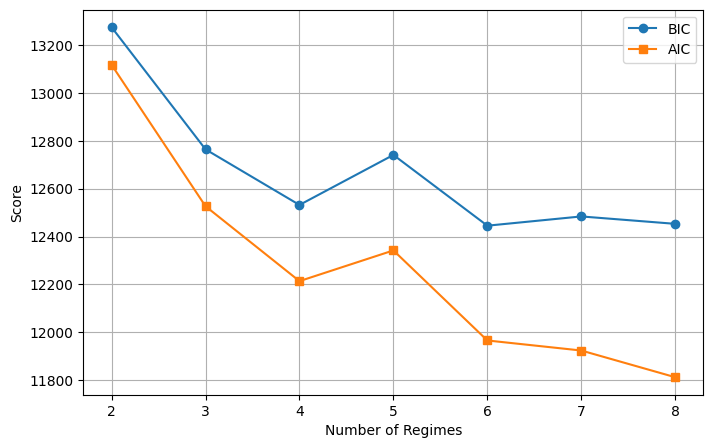

Best K by BIC: 6


In [45]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

bic = []
aic = []

components = range(2, 9)

for k in components:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",   # justified now: PCA components are uncorrelated
        n_init=10,                # multiple restarts -> avoid bad local optima / spurious tiny clusters
        random_state=42
    )
    gmm.fit(X_pca)
    bic.append(gmm.bic(X_pca))
    aic.append(gmm.aic(X_pca))

plt.figure(figsize=(8,5))
plt.plot(components, bic, marker="o", label="BIC")
plt.plot(components, aic, marker="s", label="AIC")
plt.xlabel("Number of Regimes")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

best_k_gmm = list(components)[int(np.argmin(bic))]
print(f"Best K by BIC: {best_k_gmm}")

In [46]:
GMM_N_COMPONENTS = best_k_gmm   # override manually if you prefer a different K off the elbow

gmm_final = GaussianMixture(
    n_components=GMM_N_COMPONENTS,
    covariance_type="diag",
    n_init=10,
    random_state=42
)

main["Regime_GMM"] = gmm_final.fit_predict(X_pca)

print(main["Regime_GMM"].value_counts().sort_index())

Regime_GMM
0    146
1     74
2      4
3    153
4    100
5     37
Name: count, dtype: int64


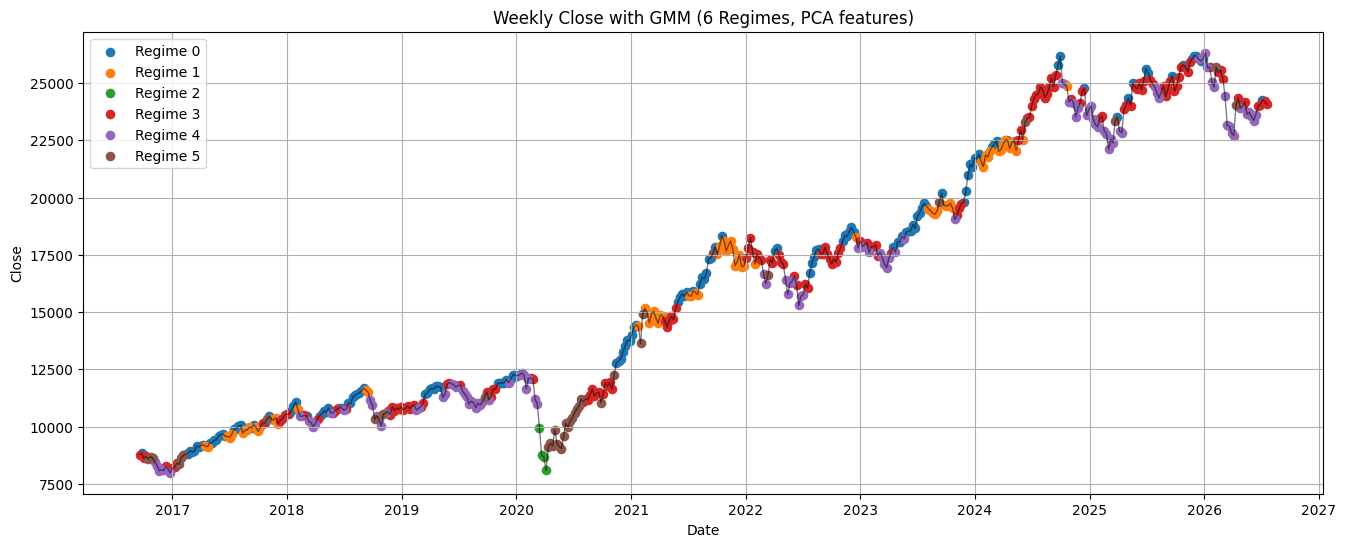

In [47]:
plt.figure(figsize=(16,6))

for regime in sorted(main["Regime_GMM"].unique()):
    mask = main["Regime_GMM"] == regime
    plt.scatter(main.loc[mask, "Date"], main.loc[mask, "Close"], s=35, label=f"Regime {regime}")

plt.plot(main["Date"], main["Close"], color="black", linewidth=1, alpha=0.5)
plt.title(f"Weekly Close with GMM ({GMM_N_COMPONENTS} Regimes, PCA features)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.grid(True)
plt.show()

## HMM — model selection (on PCA features)

In [48]:
from hmmlearn.hmm import GaussianHMM

def hmm_bic_aic(model, X):
    """Manual BIC/AIC for GaussianHMM with diag covariance.
    hmmlearn has no built-in .bic()/.aic(), and raw log-likelihood always
    improves with more states (like an unpenalized fit) so it can't be used
    alone to pick n_components."""
    n = model.n_components
    d = X.shape[1]
    n_samples = X.shape[0]

    # start probs (n-1) + transitions (n*(n-1)) + means (n*d) + diag covars (n*d)
    n_params = (n - 1) + n * (n - 1) + 2 * n * d
    log_likelihood = model.score(X)   # total log-likelihood, not averaged

    bic = -2 * log_likelihood + n_params * np.log(n_samples)
    aic = -2 * log_likelihood + 2 * n_params
    return bic, aic

In [49]:
RESTART_SEEDS = [42, 7, 123, 2024, 99]   # multiple restarts -> keep best-converged fit per K

hmm_candidates = range(2, 7)

hmm_bics, hmm_aics, hmm_scores = [], [], []

for n in hmm_candidates:
    best_model, best_score = None, -np.inf

    for seed in RESTART_SEEDS:
        model = GaussianHMM(
            n_components=n,
            covariance_type="diag",   # matches final model now (was "full" before -> mismatch bug)
            n_iter=500,
            tol=1e-3,
            random_state=seed
        )
        model.fit(X_pca)
        score = model.score(X_pca)

        if score > best_score:
            best_score, best_model = score, model

    bic, aic = hmm_bic_aic(best_model, X_pca)

    hmm_scores.append(best_score)
    hmm_bics.append(bic)
    hmm_aics.append(aic)

    print(f"n={n}: log-likelihood={best_score:.1f}  BIC={bic:.1f}  AIC={aic:.1f}")

n=2: log-likelihood=-6152.7  BIC=12548.8  AIC=12383.4
n=3: log-likelihood=-6034.2  BIC=12455.4  AIC=12192.4
n=4: log-likelihood=-5779.2  BIC=12101.5  AIC=11732.4
n=5: log-likelihood=-5677.0  BIC=12065.6  AIC=11582.0
n=6: log-likelihood=-5521.2  BIC=11935.1  AIC=11328.5


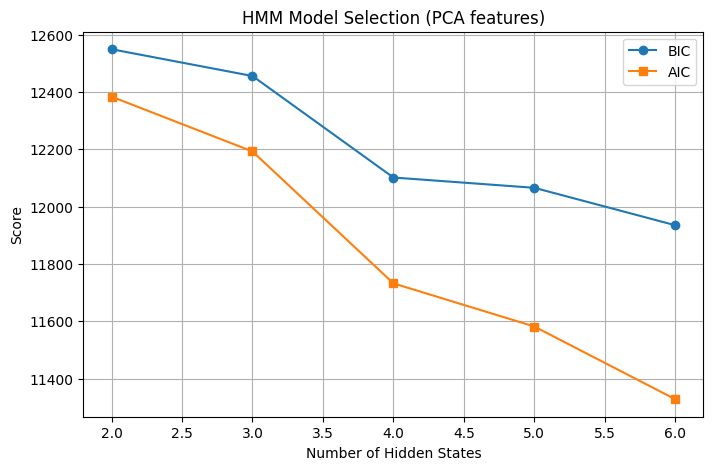

Best n_components by BIC: 6


In [50]:
plt.figure(figsize=(8,5))

plt.plot(list(hmm_candidates), hmm_bics, marker="o", label="BIC")
plt.plot(list(hmm_candidates), hmm_aics, marker="s", label="AIC")

plt.xlabel("Number of Hidden States")
plt.ylabel("Score")
plt.title("HMM Model Selection (PCA features)")
plt.legend()
plt.grid(True)
plt.show()

best_n_hmm = list(hmm_candidates)[int(np.argmin(hmm_bics))]
print(f"Best n_components by BIC: {best_n_hmm}")

## Fit final HMM

Fixes the earlier bug where the transition matrix / state means were read off a leftover model-selection variable (`hmm`) instead of the model actually used to label the data (`hmm5`). Everything below reads from `hmm_final`, which is also what produces `HMM_State`.

In [51]:
HMM_N_COMPONENTS = best_n_hmm   # override manually if you prefer a different K

best_score = -np.inf
hmm_final = None

for seed in RESTART_SEEDS:
    model = GaussianHMM(
        n_components=HMM_N_COMPONENTS,
        covariance_type="diag",
        n_iter=1000,
        tol=1e-3,
        random_state=seed
    )
    model.fit(X_pca)
    score = model.score(X_pca)

    if score > best_score:
        best_score, hmm_final = score, model

main["HMM_State"] = hmm_final.predict(X_pca)

print(main["HMM_State"].value_counts().sort_index())

HMM_State
0    127
1      4
2    179
3     72
4    116
5     16
Name: count, dtype: int64


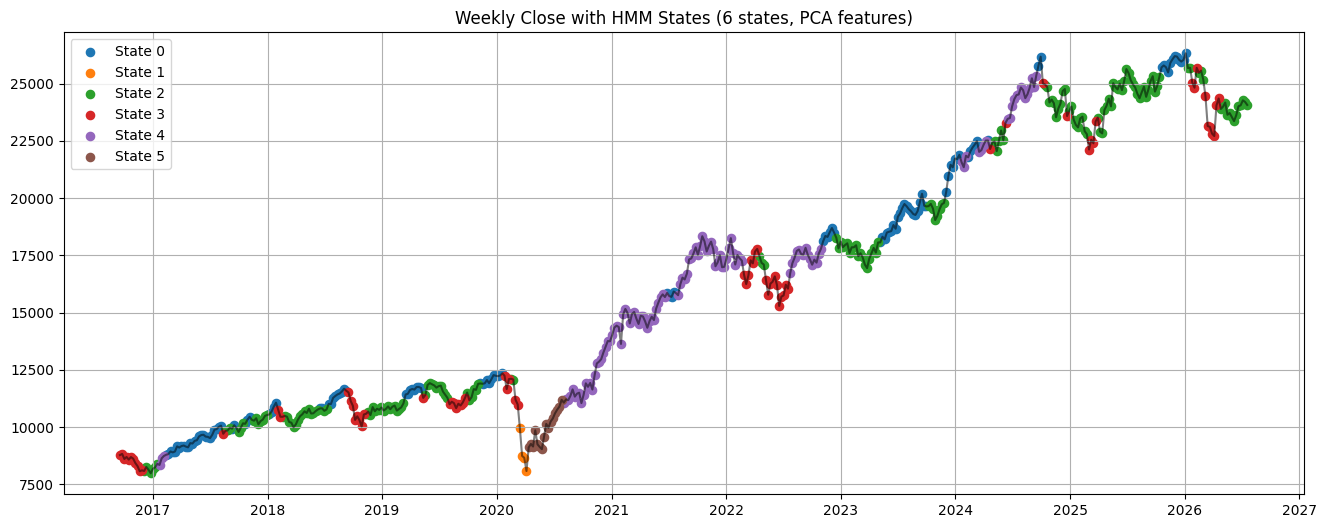

In [52]:
plt.figure(figsize=(16,6))

for state in sorted(main["HMM_State"].unique()):
    mask = main["HMM_State"] == state
    plt.scatter(main.loc[mask, "Date"], main.loc[mask, "Close"], s=35, label=f"State {state}")

plt.plot(main["Date"], main["Close"], color="black", alpha=0.5)
plt.title(f"Weekly Close with HMM States ({HMM_N_COMPONENTS} states, PCA features)")
plt.legend()
plt.grid(True)
plt.show()

### State interpretation (in original, human-readable features — not PCA components)

In [53]:
state_summary = (
    main
    .groupby("HMM_State")[FEATURE_COLUMNS]
    .mean()
    .round(2)
)

state_summary

,EMA_Distance,HH_HL_Score,ADX,ADX_Slope,ADX_Streak,ATR,ATR_Slope,Weekly_Range,Range_Relative,BB_Width,ROC_1,ROC_4,Candle_Streak,Efficiency_Ratio,Rolling_R2,Relative_Volume
HMM_State,,,,,,,,,,,,,,,,
0,6.77,0.87,24.85,0.58,4.74,2.11,-0.03,1.78,1.08,2.55,0.57,2.65,0.99,0.63,0.67,1.00
1,-22.22,-1.50,31.22,3.28,5.50,7.24,1.23,16.91,1.56,3.09,-7.30,-23.64,-2.25,1.00,0.93,0.96
2,1.94,0.04,17.86,-0.49,-3.14,2.56,-0.00,2.39,1.05,1.68,0.10,0.14,0.12,0.35,0.39,0.99
3,-1.18,-0.69,18.25,0.32,0.99,2.81,0.10,3.92,1.42,1.58,-0.72,-2.48,-0.74,0.44,0.53,1.06
4,9.49,0.74,26.37,-0.01,-5.20,3.11,-0.02,2.98,1.13,4.31,0.58,2.43,0.74,0.47,0.49,1.00
5,-6.83,1.00,35.73,-0.39,-1.44,6.62,-0.17,4.95,1.02,5.99,2.14,5.53,1.25,0.48,0.57,1.00


In [54]:
pd.DataFrame(
    hmm_final.transmat_,
    index=[f"State {i}" for i in range(hmm_final.n_components)],
    columns=[f"State {i}" for i in range(hmm_final.n_components)]
).round(3)

,State 0,State 1,State 2,State 3,State 4,State 5
State 0,0.870,0.000,0.038,0.070,0.022,0.000
State 1,0.000,0.750,0.000,0.000,0.000,0.250
State 2,0.059,0.000,0.888,0.047,0.006,0.000
State 3,0.000,0.013,0.197,0.763,0.028,0.000
State 4,0.051,0.000,0.000,0.010,0.939,0.000
State 5,0.000,0.000,0.000,0.000,0.061,0.939


In [55]:
main["Next_Return"] = main["Close"].pct_change().shift(-1) * 100

state_performance = (
    main.groupby("HMM_State")["Next_Return"]
    .agg(["count", "mean", "median", "std"])
)

state_performance

,count,mean,median,std
HMM_State,,,,
0,127,0.227250,0.267611,1.298506
1,4,-1.766102,-3.815248,10.680146
2,178,0.047121,0.325956,1.732558
3,72,-0.110475,0.049732,2.697401
4,116,0.603901,1.018884,2.111771
5,16,1.280863,1.433961,3.438637


## Out-of-sample sanity check

Scaler, PCA, and HMM are all refit on the **first 80% of weeks only**, then scored on the held-out last 20%. A big gap between train and test average log-likelihood is a sign the model (still) doesn't generalize — worth checking given how small the sample is relative to model complexity. This is a diagnostic only; it doesn't replace the full-sample model above, since regime labels here are descriptive/historical rather than a live forecasting signal.

In [56]:
SPLIT = int(len(main) * 0.8)

train_idx = main.index[:SPLIT]
test_idx = main.index[SPLIT:]

# Refit scaler + PCA on TRAIN ONLY to avoid leakage into the test window
scaler_oos = RobustScaler()
X_train_scaled = scaler_oos.fit_transform(main.loc[train_idx, FEATURE_COLUMNS])
X_test_scaled = scaler_oos.transform(main.loc[test_idx, FEATURE_COLUMNS])

pca_oos = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca_oos.fit_transform(X_train_scaled)
X_test_pca = pca_oos.transform(X_test_scaled)

hmm_oos = GaussianHMM(
    n_components=HMM_N_COMPONENTS,
    covariance_type="diag",
    n_iter=1000,
    tol=1e-3,
    random_state=42
)
hmm_oos.fit(X_train_pca)

train_ll = hmm_oos.score(X_train_pca) / len(X_train_pca)
test_ll = hmm_oos.score(X_test_pca) / len(X_test_pca)

print(f"Train avg log-likelihood/sample: {train_ll:.3f}")
print(f"Test  avg log-likelihood/sample: {test_ll:.3f}")
print(f"Gap (train - test): {train_ll - test_ll:.3f}   (large gap -> overfitting)")

Train avg log-likelihood/sample: -10.675
Test  avg log-likelihood/sample: -9.195
Gap (train - test): -1.479   (large gap -> overfitting)


In [57]:
overall_mean = main[FEATURE_COLUMNS].mean()
overall_std = main[FEATURE_COLUMNS].std()

state_z = (
    main.groupby("HMM_State")[FEATURE_COLUMNS].mean() - overall_mean
) / overall_std

state_z = state_z.round(2)
state_z

,EMA_Distance,HH_HL_Score,ADX,ADX_Slope,ADX_Streak,ATR,ATR_Slope,Weekly_Range,Range_Relative,BB_Width,ROC_1,ROC_4,Candle_Streak,Efficiency_Ratio,Rolling_R2,Relative_Volume
HMM_State,,,,,,,,,,,,,,,,
0,0.47,0.31,0.27,0.47,0.81,-0.63,-0.27,-0.53,-0.09,-0.04,0.16,0.40,0.28,0.53,0.48,-0.04
1,-4.31,-1.04,0.93,2.78,0.92,4.29,8.39,7.56,0.74,0.26,-3.51,-5.62,-1.18,1.75,1.28,-0.24
2,-0.33,-0.16,-0.45,-0.44,-0.31,-0.20,-0.04,-0.21,-0.13,-0.52,-0.05,-0.17,-0.11,-0.40,-0.36,-0.07
3,-0.84,-0.58,-0.41,0.25,0.28,0.04,0.66,0.61,0.50,-0.57,-0.44,-0.77,-0.50,-0.08,0.05,0.32
4,0.92,0.24,0.43,-0.03,-0.60,0.32,-0.18,0.11,-0.00,0.93,0.17,0.35,0.17,0.03,-0.07,-0.03
5,-1.78,0.39,1.40,-0.35,-0.07,3.70,-1.19,1.16,-0.19,1.85,0.90,1.06,0.40,0.05,0.18,-0.02


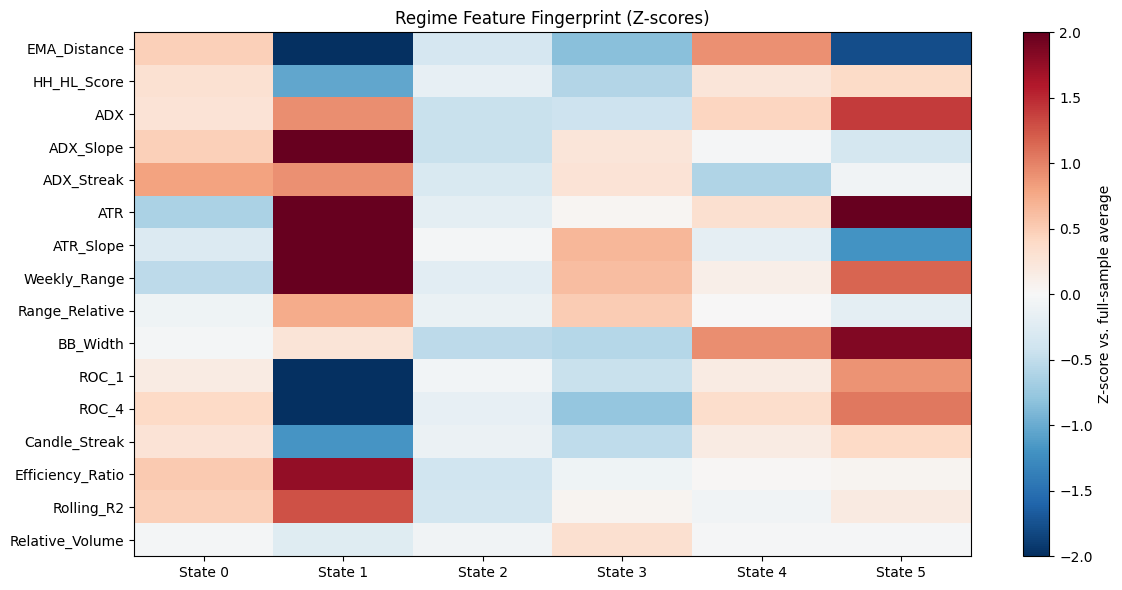

In [58]:
plt.figure(figsize=(12, 6))
plt.imshow(state_z.T, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
plt.colorbar(label="Z-score vs. full-sample average")
plt.yticks(range(len(state_z.columns)), state_z.columns)
plt.xticks(range(len(state_z.index)), [f"State {i}" for i in state_z.index])
plt.title("Regime Feature Fingerprint (Z-scores)")
plt.tight_layout()
plt.show()

In [59]:
persistence = np.diag(hmm_final.transmat_)
expected_duration = 1 / (1 - persistence)

state_stats = pd.DataFrame({
    "Count": main["HMM_State"].value_counts().sort_index(),
    "Persistence": persistence.round(3),
    "Exp_Duration_Wks": expected_duration.round(1),
})

state_stats = state_stats.join(
    state_performance.add_prefix("NextRet_")
)

state_stats

,Count,Persistence,Exp_Duration_Wks,NextRet_count,NextRet_mean,NextRet_median,NextRet_std
HMM_State,,,,,,,
0,127,0.870,7.7,127,0.227250,0.267611,1.298506
1,4,0.750,4.0,4,-1.766102,-3.815248,10.680146
2,179,0.888,8.9,178,0.047121,0.325956,1.732558
3,72,0.763,4.2,72,-0.110475,0.049732,2.697401
4,116,0.939,16.4,116,0.603901,1.018884,2.111771
5,16,0.939,16.4,16,1.280863,1.433961,3.438637


In [62]:
# Fill in based on state_z + state_stats above
REGIME_LABELS = {
    0: "Quiet Uptrend",
    1: "Crash / Panic Selloff",
    2: "Range-Bound / Consolidation",
    3: "Early Downtrend / Distribution",
    4: "Established Bull Trend",
    5: "Volatile Recovery Rally",
}

main["Regime_Label"] = main["HMM_State"].map(REGIME_LABELS)

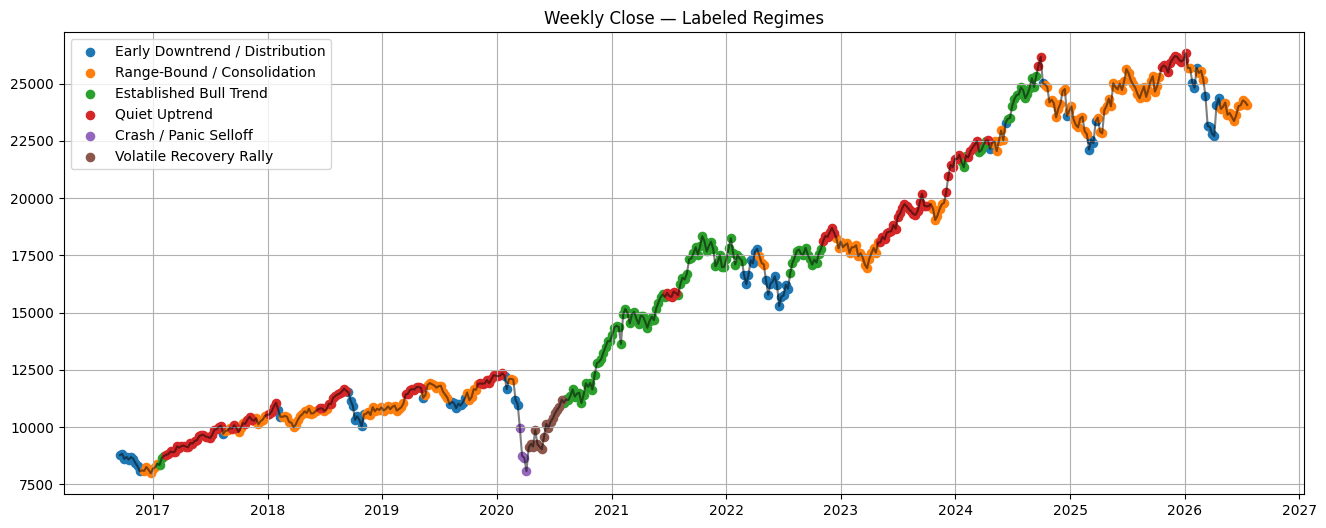

In [63]:
plt.figure(figsize=(16,6))

for label in main["Regime_Label"].dropna().unique():
    mask = main["Regime_Label"] == label
    plt.scatter(main.loc[mask, "Date"], main.loc[mask, "Close"], s=35, label=label)

plt.plot(main["Date"], main["Close"], color="black", alpha=0.5)
plt.title("Weekly Close — Labeled Regimes")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
import joblib
import sklearn, hmmlearn
from datetime import date

MODEL_PATH = f"regime_model_{date.today().isoformat()}.joblib"

bundle = {
    # fitted transformers + model
    "scaler": scaler,
    "pca": pca,
    "hmm_final": hmm_final,

    # metadata needed to use the model correctly later
    "feature_columns": FEATURE_COLUMNS,
    "n_pca_components": N_COMPONENTS,
    "hmm_n_components": HMM_N_COMPONENTS,
    "regime_labels": REGIME_LABELS,

    # library versions, so a broken load tells you WHY, not just that it's broken
    "sklearn_version": sklearn.__version__,
    "hmmlearn_version": hmmlearn.__version__,
    "trained_on": date.today().isoformat(),
    "training_rows": len(main),
}

joblib.dump(bundle, MODEL_PATH)
print(f"Saved to {MODEL_PATH}")

Saved to regime_model_2026-07-17.joblib


In [65]:
loaded = joblib.load(MODEL_PATH)

# Warn (don't just silently proceed) if the running environment doesn't match training
if loaded["sklearn_version"] != sklearn.__version__:
    print(f"WARNING: trained with sklearn {loaded['sklearn_version']}, "
          f"running {sklearn.__version__} -- results may differ")
if loaded["hmmlearn_version"] != hmmlearn.__version__:
    print(f"WARNING: trained with hmmlearn {loaded['hmmlearn_version']}, "
          f"running {hmmlearn.__version__} -- results may differ")

print("Loaded model trained on:", loaded["trained_on"], "|", loaded["training_rows"], "rows")
print("Regime labels:", loaded["regime_labels"])

Loaded model trained on: 2026-07-17 | 514 rows
Regime labels: {0: 'Quiet Uptrend', 1: 'Crash / Panic Selloff', 2: 'Range-Bound / Consolidation', 3: 'Early Downtrend / Distribution', 4: 'Established Bull Trend', 5: 'Volatile Recovery Rally'}
